# Florida outage recovery exploration

This notebook does exploratory plotting only.

It:
- loads a small Florida subset from `POUS.csv`
- pulls only the needed county and time window from `timeseries.pq`
- standardizes timestamps and FIPS codes
- joins weather on `event_id + geoid + datetime`
- makes a few dual-axis plots: `outageFraction` and `gust_mps`

It stops after plotting a small number of events.


In [1]:
from pathlib import Path
from typing import Iterable, Optional

import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.dataset as ds

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
plt.style.use('default')

POUS_PATH = Path(r'C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\POUS.csv')
TS_PATH = Path(r'C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\timeseries.pq')
WEATHER_PATH = Path(r'C:\Users\teaching\Downloads\outage-recovery-forecasting\data_raw\toy_tft_florida_event_weather_era5_hourly.csv')

FL_STATE_FIPS = '12'
STORM_HINT = '2017242N16333'
DATE_START = pd.Timestamp('2017-09-09')
DATE_END = pd.Timestamp('2017-09-13')
MAX_EVENTS_TO_PLOT = 4
PAD_BEFORE_HOURS = 24
PAD_AFTER_HOURS = 48


In [16]:
def standardize_fips(series: pd.Series) -> pd.Series:
    return series.astype('string').str.strip().str.zfill(5)


def standardize_hourly_datetime(series: pd.Series) -> pd.Series:
    dt = pd.to_datetime(series, errors='coerce')
    return dt.dt.floor('h')


def read_pous(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if 'CountyFIPS' not in df.columns:
        raise KeyError('POUS.csv must contain CountyFIPS as a column.')
    if 'event_start' not in df.columns:
        raise KeyError('POUS.csv must contain event_start as a column.')
    df = df.copy()
    df['CountyFIPS'] = standardize_fips(df['CountyFIPS'])
    df['event_start'] = pd.to_datetime(df['event_start'], errors='coerce')
    df['storm'] = df['storm'].astype('string')
    return df


def read_weather(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {'event_id', 'storm', 'geoid', 'datetime', 'event_start'}
    missing = required.difference(df.columns)
    if missing:
        raise KeyError(f'Weather file missing columns: {sorted(missing)}')
    df = df.copy()
    df['event_id'] = df['event_id'].astype('string')
    df['storm'] = df['storm'].astype('string')
    df['geoid'] = standardize_fips(df['geoid'])
    df['datetime'] = standardize_hourly_datetime(df['datetime'])
    df['event_start'] = standardize_hourly_datetime(df['event_start'])
    return df


def infer_event_id_for_row(row: pd.Series, weather: pd.DataFrame) -> pd.Series:
    exact = weather[
        (weather['storm'] == row['storm'])
        & (weather['event_start'] == row['event_start'].floor('h'))
        & (weather['geoid'] == row['CountyFIPS'])
    ]
    if exact.empty:
        exact = weather[
            (weather['storm'] == row['storm'])
            & (weather['event_start'] == row['event_start'].floor('h'))
        ]
    ids = exact['event_id'].dropna().unique()
    return ids[0] if len(ids) else pd.NA


def get_dataset_fields(dataset: ds.Dataset) -> tuple[str, str]:
    names = set(dataset.schema.names)
    date_field = None
    county_field = None
    for candidate in ['RecordDateTime', '__index_level_0__', 'datetime']:
        if candidate in names:
            date_field = candidate
            break
    for candidate in ['CountyFIPS', '__index_level_1__', 'geoid']:
        if candidate in names:
            county_field = candidate
            break
    if date_field is None or county_field is None:
        raise KeyError(f'Could not identify index fields in parquet schema. Available fields: {sorted(names)}')
    return date_field, county_field


def load_outage_window(
    pq_path: Path,
    county_fips: str,
    window_start: pd.Timestamp,
    window_end: pd.Timestamp,
) -> pd.DataFrame:
    dataset = ds.dataset(pq_path, format='parquet')
    date_field, county_field = get_dataset_fields(dataset)

    county_type = dataset.schema.field(county_field).type
    county_value: object = int(county_fips) if pa.types.is_integer(county_type) else str(county_fips)

    filter_expr = (
        (ds.field(county_field) == county_value)
        & (ds.field(date_field) >= pd.Timestamp(window_start).to_pydatetime())
        & (ds.field(date_field) < pd.Timestamp(window_end).to_pydatetime())
    )

    table = dataset.to_table(
        columns=[date_field, county_field, 'OutageFraction', 'CustomersTracked'],
        filter=filter_expr,
    )
    df = table.to_pandas()
    if df.empty:
        return df

    df = df.rename(
        columns={
            date_field: 'datetime',
            county_field: 'CountyFIPS',
            'OutageFraction': 'outageFraction',
            'CustomersTracked': 'customersTracked',
        }
    )
    df['CountyFIPS'] = standardize_fips(df['CountyFIPS'])
    df['datetime'] = standardize_hourly_datetime(df['datetime'])
    return df.sort_values('datetime').reset_index(drop=True)


def merge_outage_weather(outage: pd.DataFrame, weather: pd.DataFrame, event_row: pd.Series) -> pd.DataFrame:
    if outage.empty:
        return outage
    event_id = event_row.get('event_id', pd.NA)
    if pd.isna(event_id):
        raise ValueError('event_id could not be inferred for the selected POUS row.')
    w = weather[
        (weather['event_id'] == event_id)
        & (weather['geoid'] == event_row['CountyFIPS'])
    ].copy()
    w = w.rename(columns={'geoid': 'CountyFIPS'})
    merged = outage.merge(w, on=['CountyFIPS', 'datetime'], how='inner', suffixes=('', '_weather'))
    return merged.sort_values('datetime').reset_index(drop=True)


def plot_dual_axis(df, title):
    df = df.sort_values("datetime")

    fig, ax1 = plt.subplots(figsize=(12, 4))

    l1 = ax1.plot(
        df["datetime"],
        df["outageFraction"],
        color="tab:orange",
        linewidth=2.2,
        label="outageFraction",
    )
    ax1.set_ylabel("outageFraction", color="tab:orange")
    ax1.tick_params(axis="y", labelcolor="tab:orange")

    ax2 = ax1.twinx()
    l2 = ax2.plot(
        df["datetime"],
        df["gust_mps"],
        color="tab:blue",
        linewidth=1.8,
        label="gust_mps",
    )
    ax2.set_ylabel("gust_mps", color="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:blue")

    ax1.set_title(title)
    ax1.set_xlabel("datetime")

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper left")

    plt.tight_layout()
    plt.show()


In [3]:
pous = read_pous(POUS_PATH)
weather = read_weather(WEATHER_PATH)

florida = pous[
    pous['CountyFIPS'].str.startswith(FL_STATE_FIPS)
    & pous['event_start'].between(DATE_START, DATE_END)
].copy()

if florida.empty:
    raise ValueError('No Florida POUS rows found in the requested date window.')

if STORM_HINT in set(florida['storm'].dropna().astype(str)):
    florida = florida[florida['storm'] == STORM_HINT].copy()

florida = florida.sort_values(['event_start', 'CountyFIPS']).copy()
florida['event_id'] = florida.apply(infer_event_id_for_row, axis=1, weather=weather)

selected = florida[florida['event_id'].notna()].drop_duplicates(subset=['event_id', 'CountyFIPS']).head(MAX_EVENTS_TO_PLOT).copy()

selected[['event_start', 'storm', 'CountyFIPS', 'event_id', 'duration_hours', 'county_pop']]


,event_start,storm,CountyFIPS,event_id,duration_hours,county_pop
37,2017-09-09 20:00:00,2017242N16333,12059,event_002,43,19651
38,2017-09-09 20:00:00,2017242N16333,12067,event_002,191,7786
40,2017-09-09 22:00:00,2017242N16333,12075,event_001,190,45260
44,2017-09-10 02:00:00,2017242N16333,12079,event_003,124,18198


In [5]:
def get_county_fips(row_or_df):
    # row case
    if hasattr(row_or_df, "index") and not isinstance(row_or_df, pd.DataFrame):
        if "CountyFIPS" in row_or_df.index:
            val = row_or_df["CountyFIPS"]
        elif "geoid" in row_or_df.index:
            val = row_or_df["geoid"]
        elif row_or_df.name is not None:
            val = row_or_df.name
        else:
            raise KeyError("No county field found in row.")
    else:
        df = row_or_df
        if "CountyFIPS" in df.columns:
            val = df["CountyFIPS"]
        elif "geoid" in df.columns:
            val = df["geoid"]
        else:
            raise KeyError(f"No county field found. Columns: {list(df.columns)}; index: {df.index.names}")
    return str(val).zfill(5)

In [8]:
print("selected columns:", list(selected.columns))
print("selected index names:", selected.index.names)

selected columns: ['event_start', 'CountyFIPS', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'duration_hours', 'n_periods', 'integral', 'pop_hours_supply_lost', 'storm', 'duration_days', 'year', 'month', 'event_id']
selected index names: [None]


In [9]:
import pyarrow.dataset as ds

dataset = ds.dataset(TS_PATH, format="parquet")
print(dataset.schema)

OutageFraction: double
CustomersTracked: double
RecordDateTime: timestamp[ns]
CountyFIPS: string
-- schema metadata --
pandas: '{"index_columns": ["RecordDateTime", "CountyFIPS"], "column_inde' + 743


In [18]:
def load_outage_window(path, county_fips, window_start, window_end):
    county_fips = str(county_fips).zfill(5)

    dataset = ds.dataset(path, format="parquet")
    print("schema names:", dataset.schema.names)

    # Use the exact field names that exist in the parquet schema
    required = {"RecordDateTime", "CountyFIPS", "OutageFraction", "CustomersTracked"}
    missing = required - set(dataset.schema.names)
    if missing:
        raise KeyError(f"Missing parquet fields: {missing}. Available: {dataset.schema.names}")

    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= window_start) &
        (ds.field("RecordDateTime") <= window_end)
    )

    table = dataset.to_table(
        filter=filt,
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction", "CustomersTracked"],
    )
    df = table.to_pandas()
    df = df.rename(columns={
        "RecordDateTime": "datetime",
        "OutageFraction": "outageFraction",
        "CustomersTracked": "customersTracked",
    })
    df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
    df["datetime"] = pd.to_datetime(df["datetime"]).dt.floor("h")
    return df

In [25]:
import pyarrow.dataset as ds
import pandas as pd

def load_outage_window(path, county_fips, window_start, window_end):
    county_fips = str(county_fips).zfill(5)

    dataset = ds.dataset(path, format="parquet")

    filt = (
        (ds.field("CountyFIPS") == county_fips) &
        (ds.field("RecordDateTime") >= window_start) &
        (ds.field("RecordDateTime") <= window_end)
    )

    table = dataset.to_table(
        filter=filt,
        columns=["RecordDateTime", "CountyFIPS", "OutageFraction", "CustomersTracked"],
    )

    df = table.to_pandas()

    # If pandas restored the parquet index metadata, bring it back to columns.
    if "CountyFIPS" not in df.columns or "RecordDateTime" not in df.columns:
        df = df.reset_index()

    # Normalize possible naming after reset_index.
    rename_map = {}
    if "RecordDateTime" in df.columns:
        rename_map["RecordDateTime"] = "datetime"
    if "OutageFraction" in df.columns:
        rename_map["OutageFraction"] = "outageFraction"
    if "CustomersTracked" in df.columns:
        rename_map["CustomersTracked"] = "customersTracked"

    df = df.rename(columns=rename_map)

    if "CountyFIPS" not in df.columns:
        raise KeyError(f"CountyFIPS missing after reset_index. Columns: {df.columns.tolist()}")
    if "datetime" not in df.columns:
        raise KeyError(f"datetime missing after reset_index. Columns: {df.columns.tolist()}")

    df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
    df["datetime"] = pd.to_datetime(df["datetime"]).dt.floor("h")

    return df[["datetime", "CountyFIPS", "outageFraction", "customersTracked"]]

In [28]:
fail_row = selected[selected["CountyFIPS"].astype(str).str.zfill(5) == "12059"].iloc[0]
county_fips = str(fail_row["CountyFIPS"]).zfill(5)
event_id = fail_row["event_id"]
event_start = pd.to_datetime(fail_row["event_start"])

duration_hours = fail_row.get("duration_hours")
if pd.isna(duration_hours) or float(duration_hours) <= 0:
    duration_hours = 24
else:
    duration_hours = float(duration_hours)

window_start = event_start - pd.Timedelta(hours=PAD_BEFORE_HOURS)
window_end = event_start + pd.Timedelta(hours=max(duration_hours, 24) + PAD_AFTER_HOURS)

outage = load_outage_window(TS_PATH, county_fips, window_start, window_end)
weather_sub = weather[
    (weather["event_id"].astype(str) == str(event_id)) &
    (weather["geoid"].astype(str).str.zfill(5) == county_fips)
].copy()

print("outage rows:", len(outage))
print("weather rows for pair:", len(weather_sub))
print("outage datetime range:", outage["datetime"].min(), outage["datetime"].max())
print("weather datetime range:", weather_sub["datetime"].min(), weather_sub["datetime"].max())
print("outage dtypes:")
print(outage[["datetime", "CountyFIPS"]].dtypes)
print("weather dtypes:")
print(weather_sub[["datetime", "geoid"]].dtypes)

print("outage datetimes sample:")
print(outage["datetime"].head(5).tolist())
print("weather datetimes sample:")
print(weather_sub["datetime"].head(5).tolist())

merged_test = outage.merge(
    weather_sub,
    left_on=["CountyFIPS", "datetime"],
    right_on=["geoid", "datetime"],
    how="inner",
)
print("manual merged rows:", len(merged_test))

outage rows: 116
weather rows for pair: 0
outage datetime range: 2017-09-08 20:00:00 2017-09-13 15:00:00
weather datetime range: NaT NaT
outage dtypes:
datetime      datetime64[ns]
CountyFIPS            object
dtype: object
weather dtypes:
datetime    datetime64[ns]
geoid       string[python]
dtype: object
outage datetimes sample:
[Timestamp('2017-09-08 20:00:00'), Timestamp('2017-09-08 21:00:00'), Timestamp('2017-09-08 22:00:00'), Timestamp('2017-09-08 23:00:00'), Timestamp('2017-09-09 00:00:00')]
weather datetimes sample:
[]
manual merged rows: 0


Plotting 3 events.
Skipping 12059 2017242N16333: no merged weather rows.


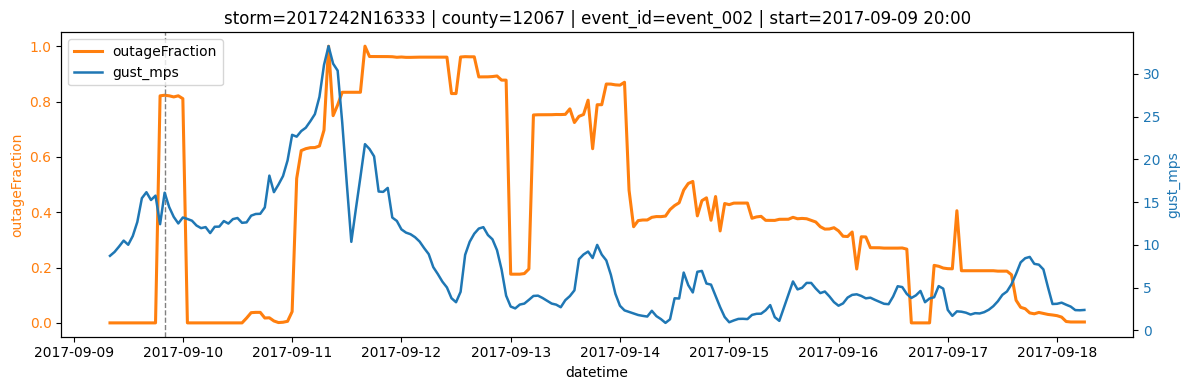

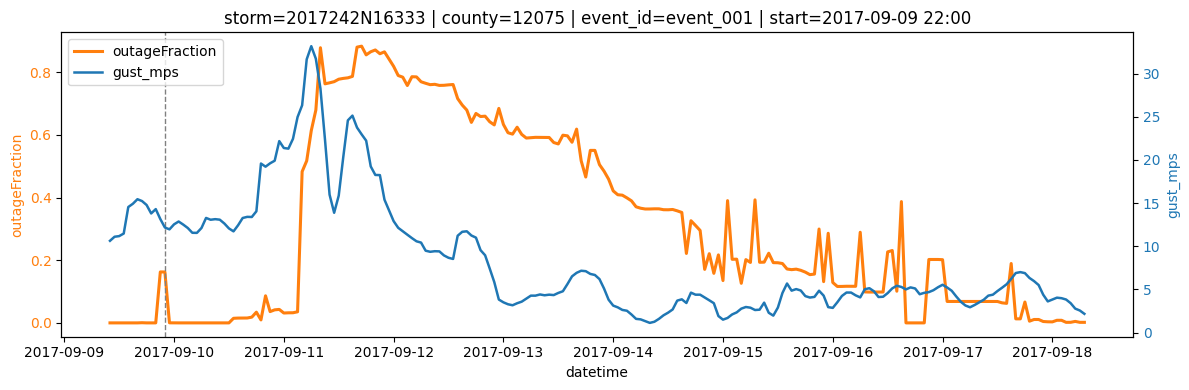

Done.


In [26]:
import matplotlib.pyplot as plt

def plot_dual_axis(df, title, event_start=None):
    df = df.sort_values("datetime").copy()

    fig, ax1 = plt.subplots(figsize=(12, 4))

    l1 = ax1.plot(
        df["datetime"],
        df["outageFraction"],
        color="tab:orange",
        linewidth=2.2,
        label="outageFraction",
    )
    ax1.set_ylabel("outageFraction", color="tab:orange")
    ax1.tick_params(axis="y", labelcolor="tab:orange")
    ax1.set_xlabel("datetime")

    if event_start is not None:
        ax1.axvline(pd.to_datetime(event_start), color="gray", linestyle="--", linewidth=1)

    ax2 = ax1.twinx()
    l2 = ax2.plot(
        df["datetime"],
        df["gust_mps"],
        color="tab:blue",
        linewidth=1.8,
        label="gust_mps",
    )
    ax2.set_ylabel("gust_mps", color="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:blue")

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper left")

    ax1.set_title(title)
    plt.tight_layout()
    plt.show()


selected_plot = selected.copy().head(3)
print(f"Plotting {len(selected_plot)} events.")

for row in selected_plot.to_dict("records"):
    county_fips = str(row["CountyFIPS"]).zfill(5)
    event_start = pd.to_datetime(row["event_start"])

    duration_hours = row.get("duration_hours")
    if pd.isna(duration_hours) or float(duration_hours) <= 0:
        duration_hours = 24
    else:
        duration_hours = float(duration_hours)

    window_start = event_start - pd.Timedelta(hours=PAD_BEFORE_HOURS)
    window_end = event_start + pd.Timedelta(hours=max(duration_hours, 24) + PAD_AFTER_HOURS)

    outage = load_outage_window(TS_PATH, county_fips, window_start, window_end)
    if outage.empty:
        print(f"Skipping {county_fips} {row['storm']}: no outage rows in window.")
        continue

    merged = merge_outage_weather(outage, weather, row)
    if merged.empty:
        print(f"Skipping {county_fips} {row['storm']}: no merged weather rows.")
        continue

    title = (
        f"storm={row['storm']} | county={county_fips} | "
        f"event_id={row['event_id']} | start={event_start:%Y-%m-%d %H:%M}"
    )
    plot_dual_axis(merged, title, event_start=event_start)

print("Done.")

Selected rows with weather coverage: 3
    event_id CountyFIPS          storm         event_start
0  event_002      12067  2017242N16333 2017-09-09 20:00:00
1  event_001      12075  2017242N16333 2017-09-09 22:00:00
2  event_003      12079  2017242N16333 2017-09-10 02:00:00


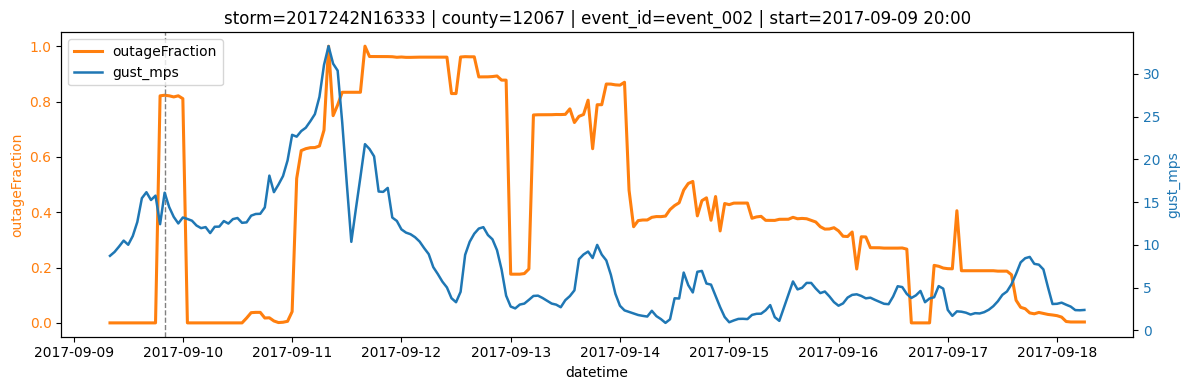

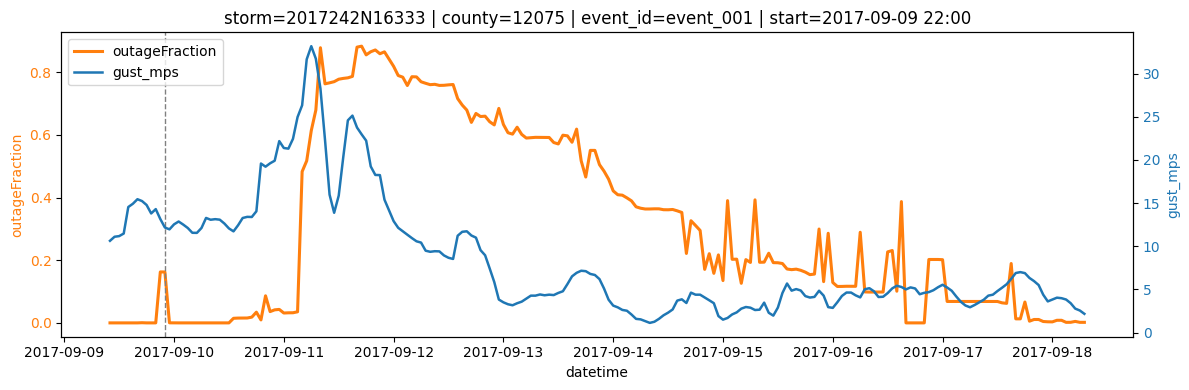

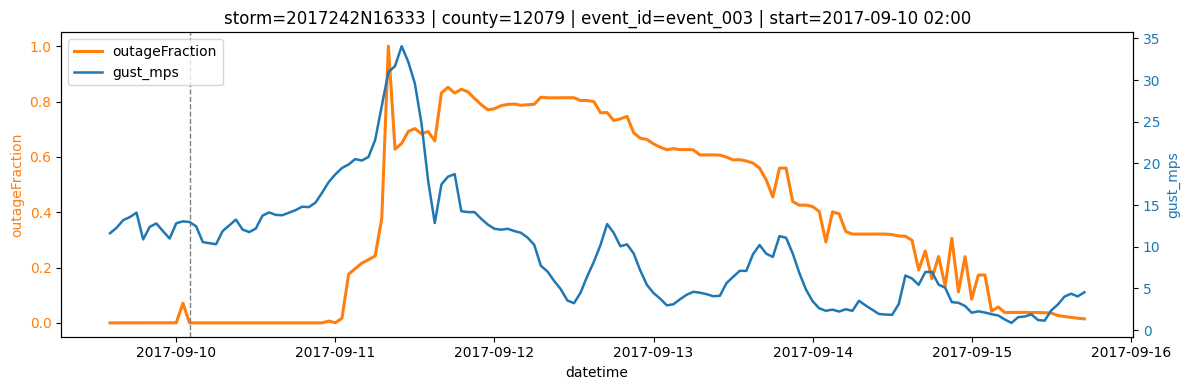

Done. Plotted 3 events.


In [29]:
# Build a set of event-county pairs that actually exist in the weather table
weather_pairs = (
    weather[["event_id", "geoid"]]
    .dropna()
    .assign(
        event_id=lambda d: d["event_id"].astype(str),
        geoid=lambda d: d["geoid"].astype(str).str.zfill(5),
    )
    .drop_duplicates()
)

selected2 = selected.copy()
selected2["CountyFIPS"] = selected2["CountyFIPS"].astype(str).str.zfill(5)
selected2["event_id"] = selected2["event_id"].astype(str)

# Keep only rows with matching weather coverage
selected2 = selected2.merge(
    weather_pairs,
    left_on=["event_id", "CountyFIPS"],
    right_on=["event_id", "geoid"],
    how="inner",
)

print(f"Selected rows with weather coverage: {len(selected2)}")
print(selected2[["event_id", "CountyFIPS", "storm", "event_start"]].head(10))

plotted = 0
for row in selected2.to_dict("records"):
    county_fips = str(row["CountyFIPS"]).zfill(5)
    event_start = pd.to_datetime(row["event_start"])

    duration_hours = row.get("duration_hours")
    if pd.isna(duration_hours) or float(duration_hours) <= 0:
        duration_hours = 24
    else:
        duration_hours = float(duration_hours)

    window_start = event_start - pd.Timedelta(hours=PAD_BEFORE_HOURS)
    window_end = event_start + pd.Timedelta(hours=max(duration_hours, 24) + PAD_AFTER_HOURS)

    outage = load_outage_window(TS_PATH, county_fips, window_start, window_end)
    if outage.empty:
        print(f"Skipping {county_fips} {row['storm']}: no outage rows in window.")
        continue

    merged = merge_outage_weather(outage, weather, row)
    if merged.empty:
        print(f"Skipping {county_fips} {row['storm']}: no merged weather rows.")
        continue

    title = (
        f"storm={row['storm']} | county={county_fips} | "
        f"event_id={row['event_id']} | start={event_start:%Y-%m-%d %H:%M}"
    )
    plot_dual_axis(merged, title, event_start=event_start)

    plotted += 1
    if plotted == 3:
        break

print(f"Done. Plotted {plotted} events.")